<a href="https://colab.research.google.com/github/SadeepM/Brain-Tumor-Segmentation-using-3D-U-Net-and-BraTS-2020/blob/main/BraTS2020_with_data_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# See if reuired libraries exist, if not, install it
try:
  import torchmetrics,mlxtend, monai
  print(f"mlxtend version: {mlxtend.__version__}")
  assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend verison should be 0.19.0 or higher"
except:
  !pip install -q torchmetrics mlxtend monai
  import torchmetrics,mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.0 MB/s eta 0:00:00
mlxtend version: 0.23.4


In [2]:
#import monai
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    NormalizeIntensityd,
    RandCropByPosNegLabeld,
    Lambdad,
    EnsureTyped,
    RandFlipd,
    RandRotate90d,
    RandScaleIntensityd,
    RandShiftIntensityd,
    RandGaussianNoised
)

from monai.data import Dataset, DataLoader,list_data_collate
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.transforms import AsDiscrete

import os
import random

# Import PyTorch
import torch
from torch import nn

# Import torchvision
import torchvision
import torch.nn.functional as F

# Import matplotlib visualization
import matplotlib.pyplot as plt

#Import Kaggle for get dataset
import kagglehub

#import sklearn
from sklearn.model_selection import train_test_split

# Import tqdm for progress bar
#from tqdm.auto import tqdm

In [3]:
# Download latest version
path = kagglehub.dataset_download("awsaf49/brats20-dataset-training-validation")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brats20-dataset-training-validation' dataset.
Path to dataset files: /kaggle/input/brats20-dataset-training-validation


In [4]:
print(os.listdir(path))

['BraTS2020_ValidationData', 'BraTS2020_TrainingData']


In [5]:
train_data_path=os.path.join(path,"BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData")
print(os.listdir(train_data_path))

['BraTS20_Training_083', 'BraTS20_Training_337', 'BraTS20_Training_161', 'BraTS20_Training_198', 'BraTS20_Training_284', 'BraTS20_Training_169', 'BraTS20_Training_157', 'BraTS20_Training_073', 'BraTS20_Training_253', 'BraTS20_Training_026', 'BraTS20_Training_100', 'BraTS20_Training_107', 'BraTS20_Training_245', 'BraTS20_Training_358', 'BraTS20_Training_310', 'BraTS20_Training_205', 'BraTS20_Training_225', 'BraTS20_Training_320', 'BraTS20_Training_162', 'BraTS20_Training_108', 'BraTS20_Training_048', 'BraTS20_Training_218', 'BraTS20_Training_289', 'BraTS20_Training_045', 'BraTS20_Training_334', 'BraTS20_Training_054', 'BraTS20_Training_354', 'BraTS20_Training_243', 'BraTS20_Training_142', 'BraTS20_Training_179', 'BraTS20_Training_307', 'BraTS20_Training_070', 'BraTS20_Training_238', 'BraTS20_Training_146', 'BraTS20_Training_195', 'BraTS20_Training_060', 'BraTS20_Training_322', 'BraTS20_Training_303', 'BraTS20_Training_215', 'BraTS20_Training_031', 'BraTS20_Training_145', 'BraTS20_Traini

In [6]:
def relabel(mask):
    return torch.where(mask == 4, torch.tensor(3, dtype=mask.dtype), mask)

In [7]:
train_transforms = Compose([

    # Load images + label
    LoadImaged(keys=["image", "label"]),

    # Make channel first (MRI is 3D)
    EnsureChannelFirstd(keys=["image", "label"]),

    # Normalize MRI intensities
    NormalizeIntensityd(
        keys="image",
        nonzero=True,
        channel_wise=True),

    # Fix BraTS labels (0,1,2,4 -> 0,1,2,3)
    Lambdad(keys="label", func=relabel),

    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(64,64,64),
        pos=3,   # tumor patches
        neg=1,   # background patches
        num_samples=4
    ),

    RandFlipd(keys=["image","label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image","label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image","label"], prob=0.5, spatial_axis=2),
    RandRotate90d(keys=["image","label"], prob=0.5, max_k=3),
    RandScaleIntensityd(keys="image", factors=0.1, prob=0.5),
    RandShiftIntensityd(keys="image", offsets=0.1, prob=0.5),
    RandGaussianNoised(keys="image", prob=0.15, std=0.01),

    # Ensure correct tensor type
    EnsureTyped(keys=["image", "label"])
])

val_transform=Compose([
    LoadImaged(keys=["image","label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    NormalizeIntensityd(
        keys="image",
        nonzero=True,
        channel_wise=True),
    Lambdad(keys="label", func=relabel),
    EnsureTyped(keys=["image", "label"])
]

)


In [8]:
train_files = []

for subject in os.listdir(train_data_path):

    if "355" in subject:
        print(f"Skipping {subject} (Inconsistent naming)")
        continue

    folder = os.path.join(train_data_path, subject)

    if os.path.isdir(folder) and subject.startswith("BraTS20"):
      train_files.append({
          "image": [
              f"{folder}/{subject}_flair.nii",
              f"{folder}/{subject}_t1.nii",
              f"{folder}/{subject}_t1ce.nii",
              f"{folder}/{subject}_t2.nii",
          ],
          "label": f"{folder}/{subject}_seg.nii"
      })

print(f"Successfully found {len(train_files)} patient folders.")

Skipping BraTS20_Training_355 (Inconsistent naming)
Successfully found 368 patient folders.


In [9]:
#split files (85% train & val, 15% test)
train_val_files,test_files=train_test_split(train_files,test_size=0.15,random_state=42)

# Split the remaining 85% into 85% training and 15% validation
# Final proportions: approximately 72.25% train, 12.75% validation, 15% test
train_files_final,val_files=train_test_split(train_val_files,test_size=0.15,random_state=42)

In [10]:
print(f"Total images: {len(train_files)}")
print(f"Training on: {len(train_files_final)}")
print(f"Validating on: {len(val_files)}")
print(f"Testing on: {len(test_files)}")

Total images: 368
Training on: 265
Validating on: 47
Testing on: 56


In [11]:
train_ds = Dataset(
    data=train_files_final,
    transform=train_transforms
)

test_ds = Dataset(
    data=test_files,
    transform=val_transform
)

val_ds = Dataset(
    data=val_files,
    transform=val_transform
)

In [12]:
train_loader = DataLoader(
    train_ds,
    batch_size=1,
    shuffle=True,
    num_workers=2,
    collate_fn=list_data_collate
)

test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False,
    num_workers=0
)

val_loader = DataLoader(
    val_ds,
    batch_size=1,
    shuffle=False,
    num_workers=0
)

In [13]:
batch = next(iter(train_loader))

print(batch["image"].shape)
print(batch["label"].shape)
print(torch.unique(batch["label"]))
print(batch["image"].max(),batch["image"].min())

torch.Size([4, 4, 64, 64, 64])
torch.Size([4, 1, 64, 64, 64])
metatensor([0., 1., 2., 3.])
metatensor(8.4953) metatensor(-5.9458)


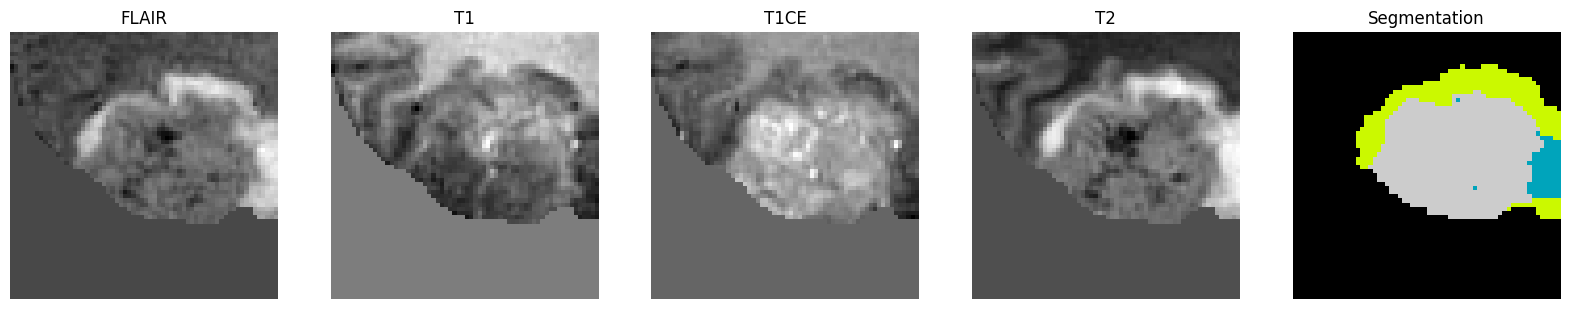

In [14]:
idx = 0

image = batch["image"][idx]   # (4, H, W, D)
mask = batch["label"][idx]    # (1, H, W, D)

slice_idx = 32  # 33rd slice

_, axes = plt.subplots(1, 5, figsize=(20, 5))

modalities = ["FLAIR", "T1", "T1CE", "T2"]

# MRI modalities
for i in range(4):
    axes[i].imshow(image[i, :, :, slice_idx].cpu(), cmap="gray")
    axes[i].set_title(modalities[i])
    axes[i].axis("off")

# Segmentation mask
axes[4].imshow(mask[0, :, :, slice_idx].cpu(), cmap="nipy_spectral")
axes[4].set_title("Segmentation")
axes[4].axis("off")

plt.show()

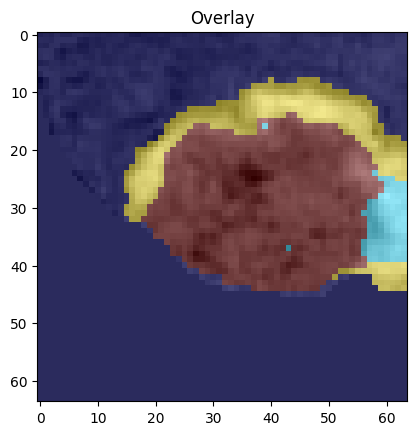

In [15]:
plt.imshow(image[0, :, :, slice_idx].cpu(), cmap="gray")
plt.imshow(mask[0, :, :, slice_idx].cpu(), alpha=0.4, cmap="jet")
plt.title("Overlay")
plt.show()

In [16]:
#Setup device agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [17]:
class DoubleConv3d(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

class UNET3D(nn.Module):
    def __init__(self, in_channels=4, out_channels=4, features=[64, 128, 256, 512]):
        super().__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool3d(kernel_size=2, stride=2)

        # Down part
        for feature in features:
            self.downs.append(DoubleConv3d(in_channels, feature))
            in_channels = feature

        # Up part
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose3d(feature * 2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv3d(feature * 2, feature))

        self.bottleneck = DoubleConv3d(features[-1], features[-1] * 2)
        self.final_conv = nn.Conv3d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx // 2]

            # If dimensions don't match (due to odd-sized inputs)
            if x.shape != skip_connection.shape:
                x = F.interpolate(x, size=skip_connection.shape[2:], mode='trilinear', align_corners=False)

            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx + 1](concat_skip)

        return self.final_conv(x)

In [18]:
# Define Model
torch.manual_seed(42)
model=UNET3D(
    in_channels=4, out_channels=4,features=[32,64, 128, 256]).to(device)
#model


In [19]:
#loss_function : Multi class Dice loss
loss_function=DiceCELoss(include_background=False,smooth_nr=1e-5, smooth_dr=1e-5, squared_pred=True, to_onehot_y=True, softmax=True)

#Optimizer
optimizer=torch.optim.Adam(model.parameters(), lr=1e-4,weight_decay=1e-5)

#Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

#Metric for validation
val_dice_metric=DiceMetric(include_background=False,reduction="mean_batch")
train_dice_metric = DiceMetric(include_background=False, reduction="mean_batch")
test_dice_metric = DiceMetric(include_background=False, reduction="mean_batch")

In [20]:
from google.colab import drive
# This connects Colab to your actual Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
checkpoint_path = "/content/drive/MyDrive/brats20_checkpoint.pth"

every_checkpoint_path = "/content/drive/MyDrive/every_brats20_checkpoint.pth"

start_epoch = 0
best_metric = -1

train_dice_scores = []
val_dice_scores = []
val_epochs=[]


if os.path.exists(every_checkpoint_path):
    print(f"Loading checkpoint: {every_checkpoint_path}")

    checkpoint = torch.load(every_checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    train_dice_scores = checkpoint.get("train_dice_scores", [])
    val_dice_scores = checkpoint.get("val_dice_scores", [])
    val_epochs = checkpoint.get("val_epochs", [])

    start_epoch = checkpoint["epoch"] + 1
    best_metric = checkpoint["best_metric"]

    print(f"Resuming from epoch {start_epoch}")
    print(f"Previous best validation Dice: {best_metric:.4f}")

elif os.path.exists(checkpoint_path):
    print(f"Loading checkpoint: {checkpoint_path}")

    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    train_dice_scores = checkpoint.get("train_dice_scores", [])
    val_dice_scores = checkpoint.get("val_dice_scores", [])
    val_epochs = checkpoint.get("val_epochs", [])

    start_epoch = checkpoint["epoch"] + 1
    best_metric = checkpoint["best_metric"]

    print(f"Resuming from epoch {start_epoch}")
    print(f"Previous best validation Dice: {best_metric:.4f}")

else:
    print("No checkpoint found. Training from scratch.")

Loading checkpoint: /content/drive/MyDrive/every_brats20_checkpoint.pth
Resuming from epoch 38
Previous best validation Dice: 0.8931


In [22]:
max_epochs=50
val_interval=2 #check validation every 2 epochs

for epoch in range(start_epoch,max_epochs):
  print("-"*10)
  print(f'epoch {epoch+1}/{max_epochs}')
  model.train()
  epoch_loss=0
  step=0

  train_dice_metric.reset()

  for batch_data in train_loader:
    step+=1
    inputs,labels=batch_data["image"].to(device),batch_data["label"].to(device)

    optimizer.zero_grad()
    outputs=model(inputs)

    loss=loss_function(outputs,labels)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
      post_pred = [AsDiscrete(argmax=True, to_onehot=4)(i) for i in outputs]
      post_label = [AsDiscrete(to_onehot=4)(i.long()) for i in labels]
      train_dice_metric(y_pred=post_pred, y=post_label)


    epoch_loss+=loss.item()
    if step%10==0:
      print(f'{step}/{len(train_ds)//train_loader.batch_size},train loss: {loss.item():.4f}')

  train_metric = train_dice_metric.aggregate().mean().item()
  train_dice_scores.append(train_metric)
  train_dice_metric.reset()

  epoch_loss/=step
  print(f'epoch {epoch+1} average loss: {epoch_loss:.4f}')

  torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_metric": best_metric,
                "train_dice_scores": train_dice_scores,
                "val_dice_scores": val_dice_scores,
                "val_epochs": val_epochs,
            }, every_checkpoint_path)
  print("Model Saved!")

  #validation logic
  if (epoch+1)%val_interval==0:
    model.eval()
    with torch.no_grad():
      for val_data in val_loader:
        val_inputs,val_labels=val_data["image"].to(device),val_data["label"].to(device)

        # Sliding window handles large volumes by breaking them into overlapping patches
        roi_size = (64, 64, 64)
        sw_batch_size = 4
        val_outputs = sliding_window_inference(val_inputs, roi_size, sw_batch_size, model)

        # Process outputs for Dice calculation
        # Convert to one-hot and discrete values

        val_post_pred = [AsDiscrete(argmax=True, to_onehot=4)(i) for i in val_outputs]
        val_post_label = [AsDiscrete(to_onehot=4)(i.long()) for i in val_labels]

        val_dice_metric(y_pred=val_post_pred, y=val_post_label)

      metric = val_dice_metric.aggregate()

      print(f"Class 1 Dice: {metric[0].item():.4f}")
      print(f"Class 2 Dice: {metric[1].item():.4f}")
      print(f"Class 3 Dice: {metric[2].item():.4f}")
      mean_metric=metric.mean().item()
      print(f"Validation Dice: {mean_metric:.4f}")

      val_dice_scores.append(mean_metric)
      val_epochs.append(epoch + 1)

      val_dice_metric.reset()

      scheduler.step(mean_metric)

      if mean_metric > best_metric:
          best_metric = mean_metric
          torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_metric": best_metric,
                "train_dice_scores": train_dice_scores,
                "val_dice_scores": val_dice_scores,
                "val_epochs": val_epochs,
            }, checkpoint_path)
          print("Best Model Saved!")

----------
epoch 39/50
10/265,train loss: 0.2463
20/265,train loss: 0.2201
30/265,train loss: 0.4075
40/265,train loss: 0.5787
50/265,train loss: 0.7262
60/265,train loss: 0.9524
70/265,train loss: 0.2937
80/265,train loss: 0.2097
90/265,train loss: 0.4980
100/265,train loss: 0.8354
110/265,train loss: 0.5389
120/265,train loss: 0.2502
130/265,train loss: 0.4330
140/265,train loss: 0.2002
150/265,train loss: 0.4150
160/265,train loss: 0.4769
170/265,train loss: 0.1323
180/265,train loss: 0.3333
190/265,train loss: 0.2377
200/265,train loss: 0.0815
210/265,train loss: 0.1974
220/265,train loss: 0.5719
230/265,train loss: 0.6370
240/265,train loss: 0.3561
250/265,train loss: 0.2230
260/265,train loss: 0.2284
epoch 39 average loss: 0.3495
Model Saved!
----------
epoch 40/50
10/265,train loss: 0.3550
20/265,train loss: 0.7717
30/265,train loss: 0.6494
40/265,train loss: 0.4362
50/265,train loss: 0.3234
60/265,train loss: 0.5352
70/265,train loss: 0.3010
80/265,train loss: 0.1479
90/265,tra

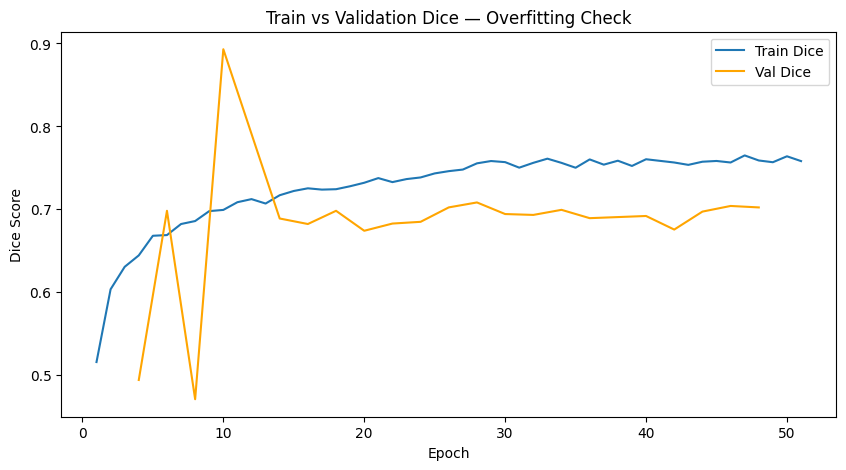

In [26]:
checkpoint_path = "/content/drive/MyDrive/brats20_checkpoint.pth"

every_checkpoint_path = "/content/drive/MyDrive/every_brats20_checkpoint.pth"

checkpoint = torch.load(
    every_checkpoint_path,
    map_location=device
)

train_dice_scores = checkpoint.get("train_dice_scores", [])
val_dice_scores = checkpoint.get("val_dice_scores", [])
val_epochs = checkpoint.get("val_epochs", [])

epochs = list(range(1, len(train_dice_scores) + 1))
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, train_dice_scores, label="Train Dice")
ax.plot(val_epochs, val_dice_scores, label="Val Dice", color="orange")
ax.set_xlabel("Epoch")
ax.set_ylabel("Dice Score")
ax.set_title("Train vs Validation Dice — Overfitting Check")
ax.legend()
plt.savefig("/content/drive/MyDrive/overfit_check.png")
plt.show()

In [24]:
#Test the model
checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

val_dice_metric.reset()

with torch.no_grad():
  for test_data in test_loader:
    test_inputs,test_labels=test_data["image"].to(device),test_data["label"].to(device)

    # Sliding window handles large volumes by breaking them into overlapping patches
    roi_size = (64, 64, 64)
    sw_batch_size = 4
    test_outputs = sliding_window_inference(test_inputs, roi_size, sw_batch_size, model)

    # Process outputs for Dice calculation
    # Convert to one-hot and discrete values

    test_post_pred = [AsDiscrete(argmax=True, to_onehot=4)(i) for i in test_outputs]
    test_post_label = [AsDiscrete(to_onehot=4)(i.long()) for i in test_labels]
    test_dice_metric(y_pred=test_post_pred, y=test_post_label)

  test_metric = test_dice_metric.aggregate()

  print(f"Class 1 Dice: {test_metric[0].item():.4f}")
  print(f"Class 2 Dice: {test_metric[1].item():.4f}")
  print(f"Class 3 Dice: {test_metric[2].item():.4f}")
  mean_metric=test_metric.mean().item()
  print(f"Test Dice: {mean_metric:.4f}")

  test_dice_metric.reset()

Class 1 Dice: 0.5959
Class 2 Dice: 0.7202
Class 3 Dice: 0.7458
Test Dice: 0.6873


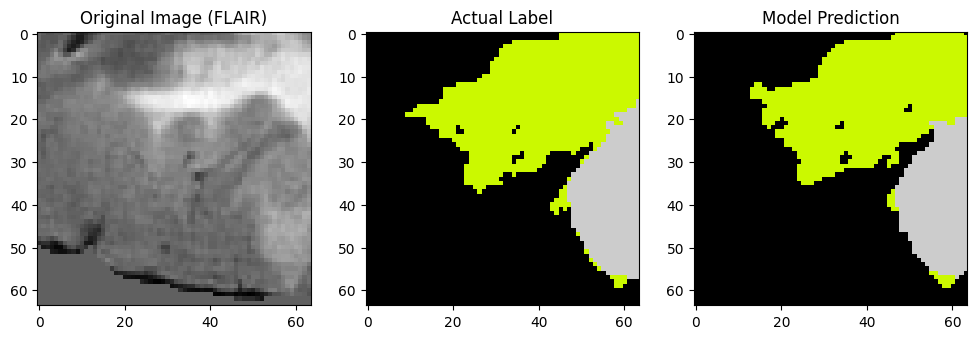

In [25]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

with torch.no_grad():
    # Get one sample
    val_data = next(iter(train_loader))
    val_inputs = val_data["image"].to(device)
    val_labels = val_data["label"].to(device)

    # Predict
    roi_size = (64, 64, 64)
    output = sliding_window_inference(val_inputs, roi_size, 4, model)
    output = torch.argmax(output, dim=1).detach().cpu().numpy()

    # Plot a slice
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 3, 1)
    plt.title("Original Image (FLAIR)")
    plt.imshow(val_inputs[0, 0, :, :, slice_idx].cpu(), cmap="gray")

    plt.subplot(1, 3, 2)
    plt.title("Actual Label")
    plt.imshow(val_labels[0, 0, :, :, slice_idx].cpu(), cmap="nipy_spectral")

    plt.subplot(1, 3, 3)
    plt.title("Model Prediction")
    plt.imshow(output[0, :, :, slice_idx], cmap="nipy_spectral")
    plt.show()